# 01 — Data Understanding
## Financial Fraud Detection Project

---

### Purpose
This notebook performs an initial exploration and profiling of the raw synthetic fraud dataset. The goal is to understand the structure, quality, distributions, and characteristics of the data **before** any cleaning or transformation.

### Dataset
`data/raw/synthetic_fraud_dataset.csv`

### Scope — What This Notebook Covers
- Dataset structure and schema inspection
- Target variable (fraud label) distribution
- Missing values and duplicate analysis
- Numerical and categorical column profiling
- Identifier and high-cardinality column detection
- Date/time column detection
- Basic correlation analysis
- Target vs. feature overview
- Data quality observations and key findings

### Out of Scope
This notebook **intentionally does NOT** perform:
- Data cleaning or imputation
- Feature engineering or encoding
- Feature scaling or normalisation
- Train/test splitting
- SMOTE or resampling
- Model training or evaluation
- Saving processed datasets

---
## 2. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.width", 120)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


---
## 3. Robust Dataset Path Setup

In [2]:
def find_project_root(marker_files=("requirements.txt", "README.md", ".gitignore"), max_levels=5):
    """
    Walk upward from the current working directory to locate the project root.
    The root is identified by the presence of one of the marker files.
    """
    current = Path.cwd().resolve()
    for _ in range(max_levels):
        if any((current / m).exists() for m in marker_files):
            return current
        parent = current.parent
        if parent == current:
            break
        current = parent
    raise FileNotFoundError(
        "Could not locate project root. Ensure you run this notebook "
        "from within the project directory tree."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "synthetic_fraud_dataset.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Please place 'synthetic_fraud_dataset.csv' inside data/raw/."
    )

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset path : {DATA_PATH}")

Project root : C:\Users\sarva\Desktop\financial-fraud-detection
Dataset path : C:\Users\sarva\Desktop\financial-fraud-detection\data\raw\synthetic_fraud_dataset.csv


---
## 4. Load the Dataset

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 50,000 rows × 14 columns


In [4]:
# First 5 rows
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,14 August 2023,93213.17,Laptop,Sydney,Travel,0,7,Amex,65,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,7 June 2023,75725.25,Mobile,New York,Clothing,0,13,Mastercard,186,1
2,TXN_199,USER_2734,28.96,Online,20 June 2023,1588.96,Tablet,Mumbai,Restaurants,0,14,Visa,226,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,7 December 2023,76807.20,Tablet,New York,Clothing,0,8,Visa,76,1
4,TXN_39489,USER_2014,31.28,POS,11 November 2023,92354.66,Mobile,Mumbai,Electronics,1,14,Mastercard,140,1


In [5]:
# Last 5 rows
df.tail()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
49995,TXN_11284,USER_4796,45.05,Online,29 January 2023,76960.11,Mobile,Tokyo,Clothing,0,2,Amex,98,0
49996,TXN_44732,USER_1171,126.15,POS,9 May 2023,28791.75,Mobile,Tokyo,Clothing,0,13,Visa,93,1
49997,TXN_38158,USER_2510,72.02,Online,30 January 2023,29916.41,Laptop,Mumbai,Clothing,1,1,Visa,114,0
49998,TXN_860,USER_2248,64.89,Bank Transfer,9 March 2023,67895.67,Mobile,Tokyo,Electronics,0,13,Discover,72,1
49999,TXN_15795,USER_6529,13.00,Bank Transfer,19 August 2023,7668.82,Tablet,London,Restaurants,0,5,Mastercard,154,1


In [6]:
# Random sample
df.sample(5, random_state=42)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
33553,TXN_35587,USER_7281,19.98,Online,10 February 2023,1804.81,Mobile,Sydney,Clothing,0,2,Mastercard,214,0
9427,TXN_32681,USER_4656,45.32,Bank Transfer,26 March 2023,46648.03,Mobile,New York,Travel,1,11,Amex,78,0
199,TXN_40971,USER_8142,32.25,ATM Withdrawal,5 August 2023,80244.56,Laptop,Tokyo,Restaurants,0,7,Amex,59,0
12447,TXN_21022,USER_4366,35.41,POS,22 January 2023,24611.99,Tablet,Mumbai,Travel,0,3,Mastercard,143,1
39489,TXN_6403,USER_4454,57.80,Bank Transfer,20 August 2023,27154.09,Tablet,Sydney,Groceries,0,1,Visa,227,0


---
## 5. Dataset Structure

In [7]:
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")

Number of rows    : 50,000
Number of columns : 14

Column names:
['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Date', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Type', 'Card_Age', 'Fraud_Label']


In [8]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Date                          50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   Previous_Fraudulent_Activity  50000 non-null  int64  
 10  Daily_Transaction_Count       50000 non-null  int64  
 11  Card_Type                     50000 non-null  str    
 12  Card_Age                      50000 non-null  int64  
 13  Fraud_Label 

In [9]:
# Summary table
structure_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Unique Values": df.nunique()
})
structure_summary.index.name = "Column"
structure_summary

,Data Type,Non-Null Count,Null Count,Unique Values
Column,,,,
Transaction_ID,str,50000,0,50000
User_ID,str,50000,0,8963
Transaction_Amount,float64,50000,0,21763
Transaction_Type,str,50000,0,4
Date,str,50000,0,365
Account_Balance,float64,50000,0,49867
Device_Type,str,50000,0,3
Location,str,50000,0,5
Merchant_Category,str,50000,0,5


---
## 6. Data Dictionary

In [10]:
data_dict_rows = []
for col in df.columns:
    example_vals = df[col].dropna().unique()[:5]
    example_str = ", ".join(str(v) for v in example_vals)
    data_dict_rows.append({
        "Column": col,
        "Data Type": str(df[col].dtype),
        "Unique Values": df[col].nunique(),
        "Example Values": example_str
    })

data_dict = pd.DataFrame(data_dict_rows).set_index("Column")
data_dict

,Data Type,Unique Values,Example Values
Column,,,
Transaction_ID,str,50000,"TXN_33553, TXN_9427, TXN_199, TXN_12447, TXN_3..."
User_ID,str,8963,"USER_1834, USER_7875, USER_2734, USER_2617, US..."
Transaction_Amount,float64,21763,"39.79, 1.19, 28.96, 254.32, 31.28"
Transaction_Type,str,4,"POS, Bank Transfer, Online, ATM Withdrawal"
Date,str,365,"14 August 2023, 7 June 2023, 20 June 2023, 7 D..."
Account_Balance,float64,49867,"93213.17, 75725.25, 1588.96, 76807.2, 92354.66"
Device_Type,str,3,"Laptop, Mobile, Tablet"
Location,str,5,"Sydney, New York, Mumbai, Tokyo, London"
Merchant_Category,str,5,"Travel, Clothing, Restaurants, Electronics, Gr..."


> **Note:** No business descriptions have been added because they are not present in the dataset itself.  
> *Likely interpretations based on column names:*
> - `Transaction_ID` — unique identifier for each transaction  
> - `User_ID` — unique identifier for each user/account holder  
> - `Transaction_Amount` — monetary value of the transaction  
> - `Transaction_Type` — category or channel of the transaction  
> - `Date` — date of the transaction  
> - `Account_Balance` — account balance at the time of the transaction  
> - `Device_Type` — device used to initiate the transaction  
> - `Location` — geographical location or city  
> - `Merchant_Category` — category of the merchant  
> - `Previous_Fraudulent_Activity` — flag indicating prior fraud history  
> - `Daily_Transaction_Count` — number of transactions on that day  
> - `Card_Type` — brand/network of the payment card  
> - `Card_Age` — age of the card (likely in days or months)  
> - `Fraud_Label` — target variable (1 = fraud, 0 = non-fraud)  
>
> These are **inferred** meanings, not confirmed metadata.

---
## 7. Target Variable Analysis

In [11]:
TARGET_COL = "Fraud_Label"

if TARGET_COL not in df.columns:
    raise ValueError(
        f"Expected target column '{TARGET_COL}' not found in the dataset. "
        f"Available columns: {list(df.columns)}"
    )

# Class counts and percentages
target_counts = df[TARGET_COL].value_counts()
target_pcts = df[TARGET_COL].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_pcts.round(2)
})
target_summary.index.name = TARGET_COL
print("Target Variable Distribution")
target_summary

Target Variable Distribution


,Count,Percentage (%)
Fraud_Label,,
0,33933,67.87
1,16067,32.13


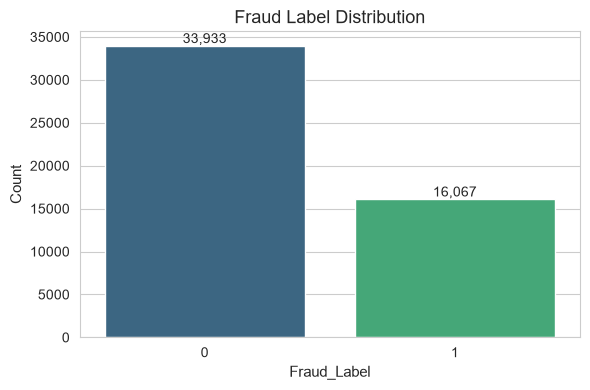

Note: Class distribution is based on this synthetic dataset only.
It should not be interpreted as representative of real-world fraud rates.


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=df[TARGET_COL], ax=ax, palette="viridis", hue=df[TARGET_COL], legend=False)
ax.set_title("Fraud Label Distribution")
ax.set_xlabel(TARGET_COL)
ax.set_ylabel("Count")

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", fontsize=10)

plt.tight_layout()
plt.show()

print("Note: Class distribution is based on this synthetic dataset only.")
print("It should not be interpreted as representative of real-world fraud rates.")

---
## 8. Missing Values Analysis

In [13]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_pct.round(2)
}).sort_values("Missing Count", ascending=False)

missing_df.index.name = "Column"
missing_df

,Missing Count,Missing Percentage (%)
Column,,
Transaction_ID,0,0.00
User_ID,0,0.00
Transaction_Amount,0,0.00
Transaction_Type,0,0.00
Date,0,0.00
Account_Balance,0,0.00
Device_Type,0,0.00
Location,0,0.00
Merchant_Category,0,0.00


In [14]:
total_missing = missing_count.sum()

if total_missing > 0:
    cols_with_missing = missing_df[missing_df["Missing Count"] > 0]
    fig, ax = plt.subplots(figsize=(8, max(3, len(cols_with_missing) * 0.5)))
    cols_with_missing["Missing Count"].plot.barh(ax=ax, color="salmon")
    ax.set_title("Missing Values by Column")
    ax.set_xlabel("Missing Count")
    ax.set_ylabel("Column")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found in any column.")

✅ No missing values found in any column.


---
## 9. Duplicate Rows Analysis

In [15]:
num_duplicates = df.duplicated().sum()
dup_pct = (num_duplicates / len(df)) * 100

print(f"Exact duplicate rows : {num_duplicates:,}")
print(f"Duplicate percentage : {dup_pct:.2f}%")

if num_duplicates > 0:
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("\n✅ No exact duplicate rows detected.")

Exact duplicate rows : 0
Duplicate percentage : 0.00%

✅ No exact duplicate rows detected.


---
## 10. Numerical Column Analysis

In [16]:
numerical_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

Numerical columns (6): ['Transaction_Amount', 'Account_Balance', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Age', 'Fraud_Label']


In [17]:
if len(numerical_cols) > 0:
    desc = df[numerical_cols].describe().T
    desc["median"] = df[numerical_cols].median()
    desc = desc[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]]
    desc
else:
    print("No numerical columns found.")

In [18]:
# Identify continuous numerical columns (exclude binary / low-cardinality)
continuous_cols = [c for c in numerical_cols if df[c].nunique() > 10]
binary_cols = [c for c in numerical_cols if df[c].nunique() <= 10]

print(f"Continuous numerical columns : {continuous_cols}")
print(f"Low-cardinality numerical cols: {binary_cols}")

Continuous numerical columns : ['Transaction_Amount', 'Account_Balance', 'Daily_Transaction_Count', 'Card_Age']
Low-cardinality numerical cols: ['Previous_Fraudulent_Activity', 'Fraud_Label']


C:\Users\sarva\AppData\Local\Temp\ipykernel_3952\96912013.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(df[col].dropna(), vert=False)
C:\Users\sarva\AppData\Local\Temp\ipykernel_3952\96912013.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(df[col].dropna(), vert=False)
C:\Users\sarva\AppData\Local\Temp\ipykernel_3952\96912013.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(df[col].dropna(), vert=False)
C:\Users\sarva\AppData\Local\Temp\ipykernel_3952\96912013.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientat

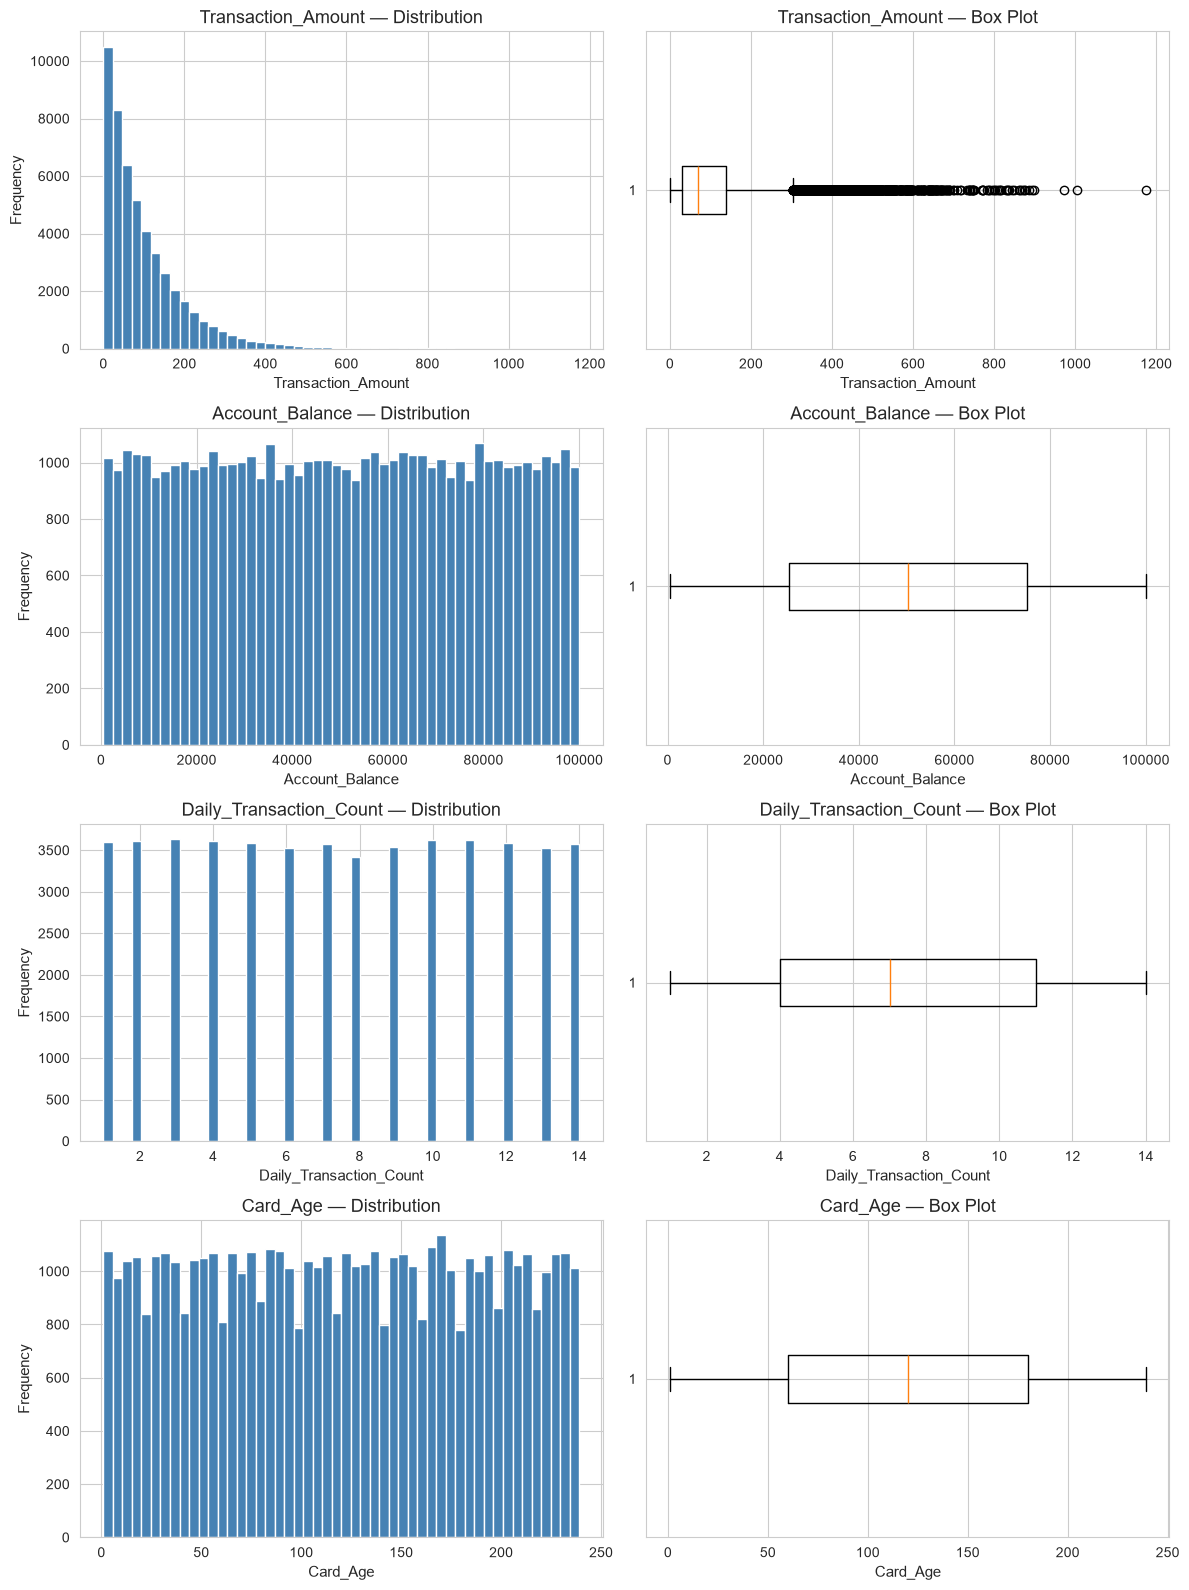

In [19]:
# Distribution plots for continuous numerical columns
if len(continuous_cols) > 0:
    n = len(continuous_cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for i, col in enumerate(continuous_cols):
        # Histogram
        axes[i, 0].hist(df[col].dropna(), bins=50, color="steelblue", edgecolor="white")
        axes[i, 0].set_title(f"{col} — Distribution")
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel("Frequency")

        # Box plot
        axes[i, 1].boxplot(df[col].dropna(), vert=False)
        axes[i, 1].set_title(f"{col} — Box Plot")
        axes[i, 1].set_xlabel(col)

    plt.tight_layout()
    plt.show()
else:
    print("No continuous numerical columns to plot.")

In [20]:
# Value counts for low-cardinality numerical columns
for col in binary_cols:
    print(f"\n--- {col} ---")
    counts = df[col].value_counts().sort_index()
    pcts = df[col].value_counts(normalize=True).sort_index() * 100
    summary = pd.DataFrame({"Count": counts, "Percentage (%)": pcts.round(2)})
    display(summary)


--- Previous_Fraudulent_Activity ---


,Count,Percentage (%)
Previous_Fraudulent_Activity,,
0,45080,90.16
1,4920,9.84



--- Fraud_Label ---


,Count,Percentage (%)
Fraud_Label,,
0,33933,67.87
1,16067,32.13


---
## 11. Categorical Column Analysis

In [21]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Categorical columns (8): ['Transaction_ID', 'User_ID', 'Transaction_Type', 'Date', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type']


C:\Users\sarva\AppData\Local\Temp\ipykernel_3952\448238298.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


In [22]:
# Unique category counts
cat_summary = pd.DataFrame({
    "Unique Values": [df[c].nunique() for c in categorical_cols],
    "Sample Value": [df[c].dropna().iloc[0] if len(df[c].dropna()) > 0 else "N/A" for c in categorical_cols]
}, index=categorical_cols)
cat_summary.index.name = "Column"
cat_summary

,Unique Values,Sample Value
Column,,
Transaction_ID,50000,TXN_33553
User_ID,8963,USER_1834
Transaction_Type,4,POS
Date,365,14 August 2023
Device_Type,3,Laptop
Location,5,Sydney
Merchant_Category,5,Travel
Card_Type,4,Amex


⚠️ High-cardinality categorical columns (>20 unique values) — skipped from bar charts: ['Transaction_ID', 'User_ID', 'Date']


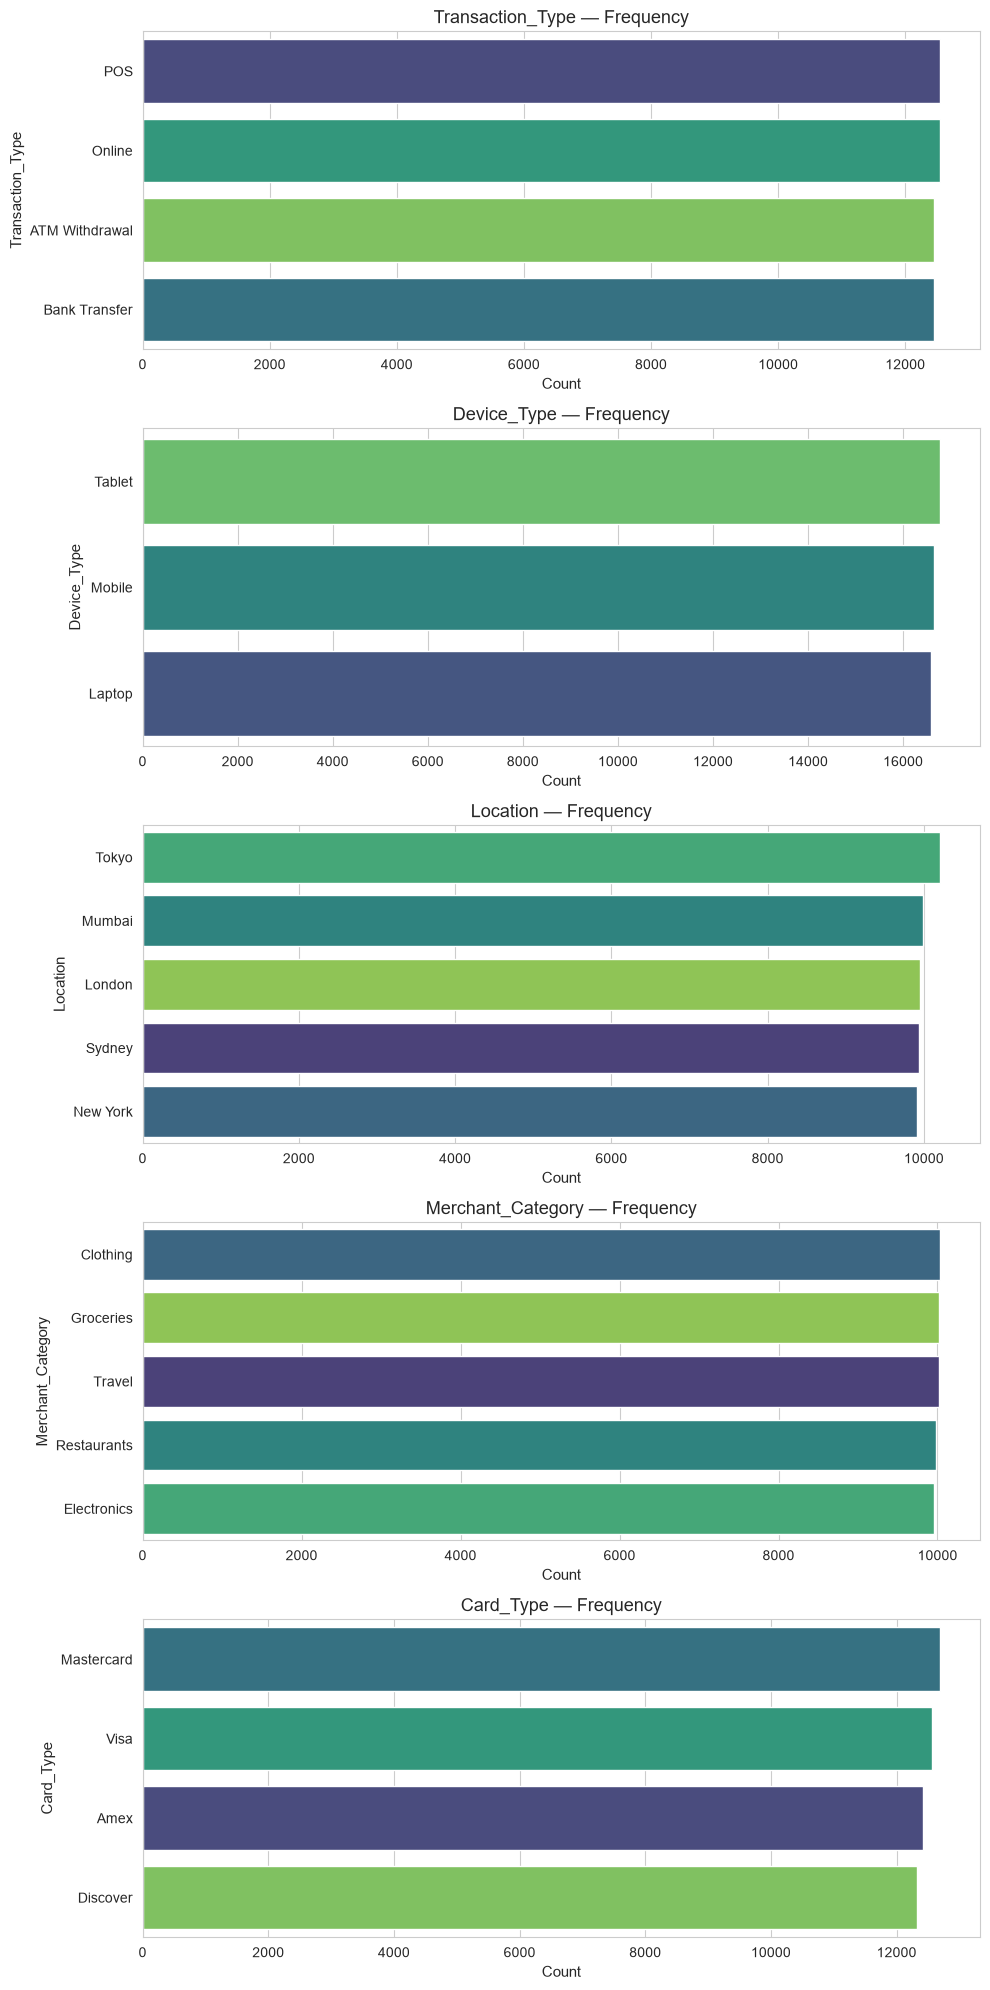

In [23]:
# Bar charts for categorical columns with a reasonable number of unique values
MAX_CATEGORIES_FOR_PLOT = 20

plottable_cats = [c for c in categorical_cols if df[c].nunique() <= MAX_CATEGORIES_FOR_PLOT]
high_card_cats = [c for c in categorical_cols if df[c].nunique() > MAX_CATEGORIES_FOR_PLOT]

if high_card_cats:
    print(f"⚠️ High-cardinality categorical columns (>{MAX_CATEGORIES_FOR_PLOT} unique values) — "
          f"skipped from bar charts: {high_card_cats}")

if len(plottable_cats) > 0:
    n = len(plottable_cats)
    fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n))
    if n == 1:
        axes = [axes]

    for i, col in enumerate(plottable_cats):
        order = df[col].value_counts().index
        sns.countplot(y=df[col], order=order, ax=axes[i], palette="viridis", hue=df[col], legend=False)
        axes[i].set_title(f"{col} — Frequency")
        axes[i].set_xlabel("Count")
        axes[i].set_ylabel(col)

    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with a plottable number of categories.")

---
## 12. Identifier and High-Cardinality Column Detection

In [24]:
id_candidates = []
n_rows = len(df)

for col in df.columns:
    n_unique = df[col].nunique()
    is_name_id = "id" in col.lower()
    is_near_unique = n_unique / n_rows >= 0.90  # ≥90% unique

    if is_name_id or is_near_unique:
        id_candidates.append({
            "Column": col,
            "Unique Values": n_unique,
            "Unique Ratio": f"{n_unique / n_rows:.2%}",
            "Name Contains 'ID'": is_name_id,
            "Near-Unique (≥90%)": is_near_unique
        })

if id_candidates:
    id_df = pd.DataFrame(id_candidates).set_index("Column")
    print("Potential identifier / high-cardinality columns")
    print("— requires careful handling in later notebooks.")
    display(id_df)
else:
    print("No obvious identifier or near-unique columns detected.")

Potential identifier / high-cardinality columns
— requires careful handling in later notebooks.


,Unique Values,Unique Ratio,Name Contains 'ID',Near-Unique (≥90%)
Column,,,,
Transaction_ID,50000,100.00%,True,True
User_ID,8963,17.93%,True,False
Account_Balance,49867,99.73%,False,True


---
## 13. Date/Time Column Detection

In [25]:
# Heuristic: check columns whose name contains date/time keywords,
# then attempt safe parsing on a sample.
date_keywords = ["date", "time", "timestamp", "dt", "created", "updated"]
potential_date_cols = [
    c for c in df.columns
    if any(kw in c.lower() for kw in date_keywords)
]

# Also try object columns not already flagged
for col in df.select_dtypes(include="object").columns:
    if col not in potential_date_cols:
        sample = df[col].dropna().head(20)
        parsed = pd.to_datetime(sample, errors="coerce", dayfirst=False)
        if parsed.notna().mean() >= 0.8:
            potential_date_cols.append(col)

print(f"Potential date/time columns: {potential_date_cols}")

for col in potential_date_cols:
    if col not in df.columns:
        continue
    parsed = pd.to_datetime(df[col], errors="coerce", dayfirst=False)
    n_valid = parsed.notna().sum()
    n_invalid = parsed.isna().sum() - df[col].isna().sum()  # truly unparseable
    print(f"\n--- {col} ---")
    print(f"  Valid parsed dates  : {n_valid:,}")
    print(f"  Unparseable values  : {n_invalid:,}")
    if n_valid > 0:
        print(f"  Minimum date        : {parsed.min()}")
        print(f"  Maximum date        : {parsed.max()}")
        print(f"  Date range          : {parsed.max() - parsed.min()}")

Potential date/time columns: ['Date']

--- Date ---
  Valid parsed dates  : 50,000
  Unparseable values  : 0
  Minimum date        : 2023-01-01 00:00:00
  Maximum date        : 2023-12-31 00:00:00
  Date range          : 364 days 00:00:00


C:\Users\sarva\AppData\Local\Temp\ipykernel_3952\2353577312.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:
C:\Users\sarva\AppData\Local\Temp\ipykernel_3952\2353577312.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(sample, errors="coerce", dayfirst=False)
C:\Users\sarva\AppData\Local\Temp\ipykernel_3952\2353577312.py:13: UserWarning: Could not inf

> **Note:** The original dataframe has **not** been modified. Date parsing was performed on temporary series only.  
> Date-based feature engineering will be addressed in a later notebook.

---
## 14. Basic Correlation Analysis

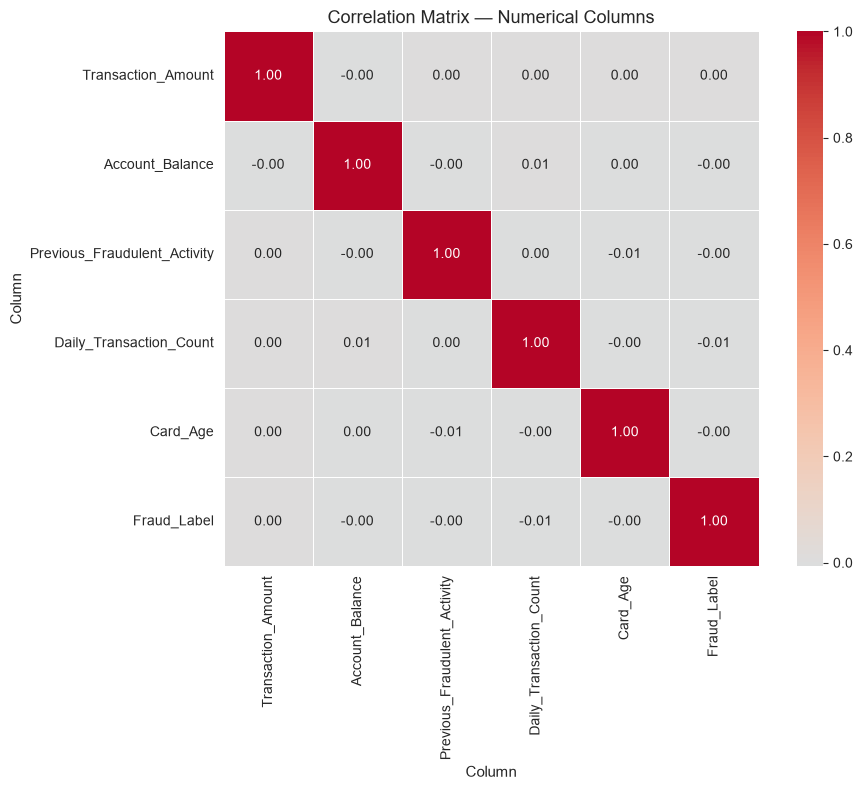


⚠️ Correlation indicates association, not causation.

Correlation with target (Fraud_Label):


,Correlation
Column,
Daily_Transaction_Count,-0.01
Account_Balance,-0.00
Card_Age,-0.00
Transaction_Amount,0.00
Previous_Fraudulent_Activity,-0.00


In [26]:
# Use only numerical columns
num_for_corr = df[numerical_cols]

if len(numerical_cols) >= 2:
    corr_matrix = num_for_corr.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title("Correlation Matrix — Numerical Columns")
    plt.tight_layout()
    plt.show()

    print("\n⚠️ Correlation indicates association, not causation.")

    if TARGET_COL in numerical_cols:
        print(f"\nCorrelation with target ({TARGET_COL}):")
        target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
        display(target_corr.to_frame("Correlation"))
else:
    print("Fewer than 2 numerical columns — skipping correlation analysis.")

---
## 15. Target vs Feature Overview

A small number of comparisons between the fraud target and key features to aid data understanding.  
This is **not** full exploratory analysis — just an initial overview.

In [27]:
def fraud_rate_bar(df, feature_col, target_col, ax, top_n=None):
    """Plot fraud rate by a categorical feature."""
    grouped = df.groupby(feature_col)[target_col].mean() * 100
    if top_n:
        grouped = grouped.sort_values(ascending=False).head(top_n)
    grouped.sort_values().plot.barh(ax=ax, color="coral")
    ax.set_title(f"Fraud Rate by {feature_col}")
    ax.set_xlabel("Fraud Rate (%)")
    ax.set_ylabel(feature_col)

In [28]:
# Define candidate features for target comparisons
cat_features_for_target = [
    "Transaction_Type",
    "Device_Type",
    "Location",
    "Merchant_Category",
    "Card_Type",
]
num_features_for_target = [
    "Transaction_Amount",
    "Account_Balance",
]

# Filter to columns that actually exist
available_cat = [c for c in cat_features_for_target if c in df.columns]
available_num = [c for c in num_features_for_target if c in df.columns]

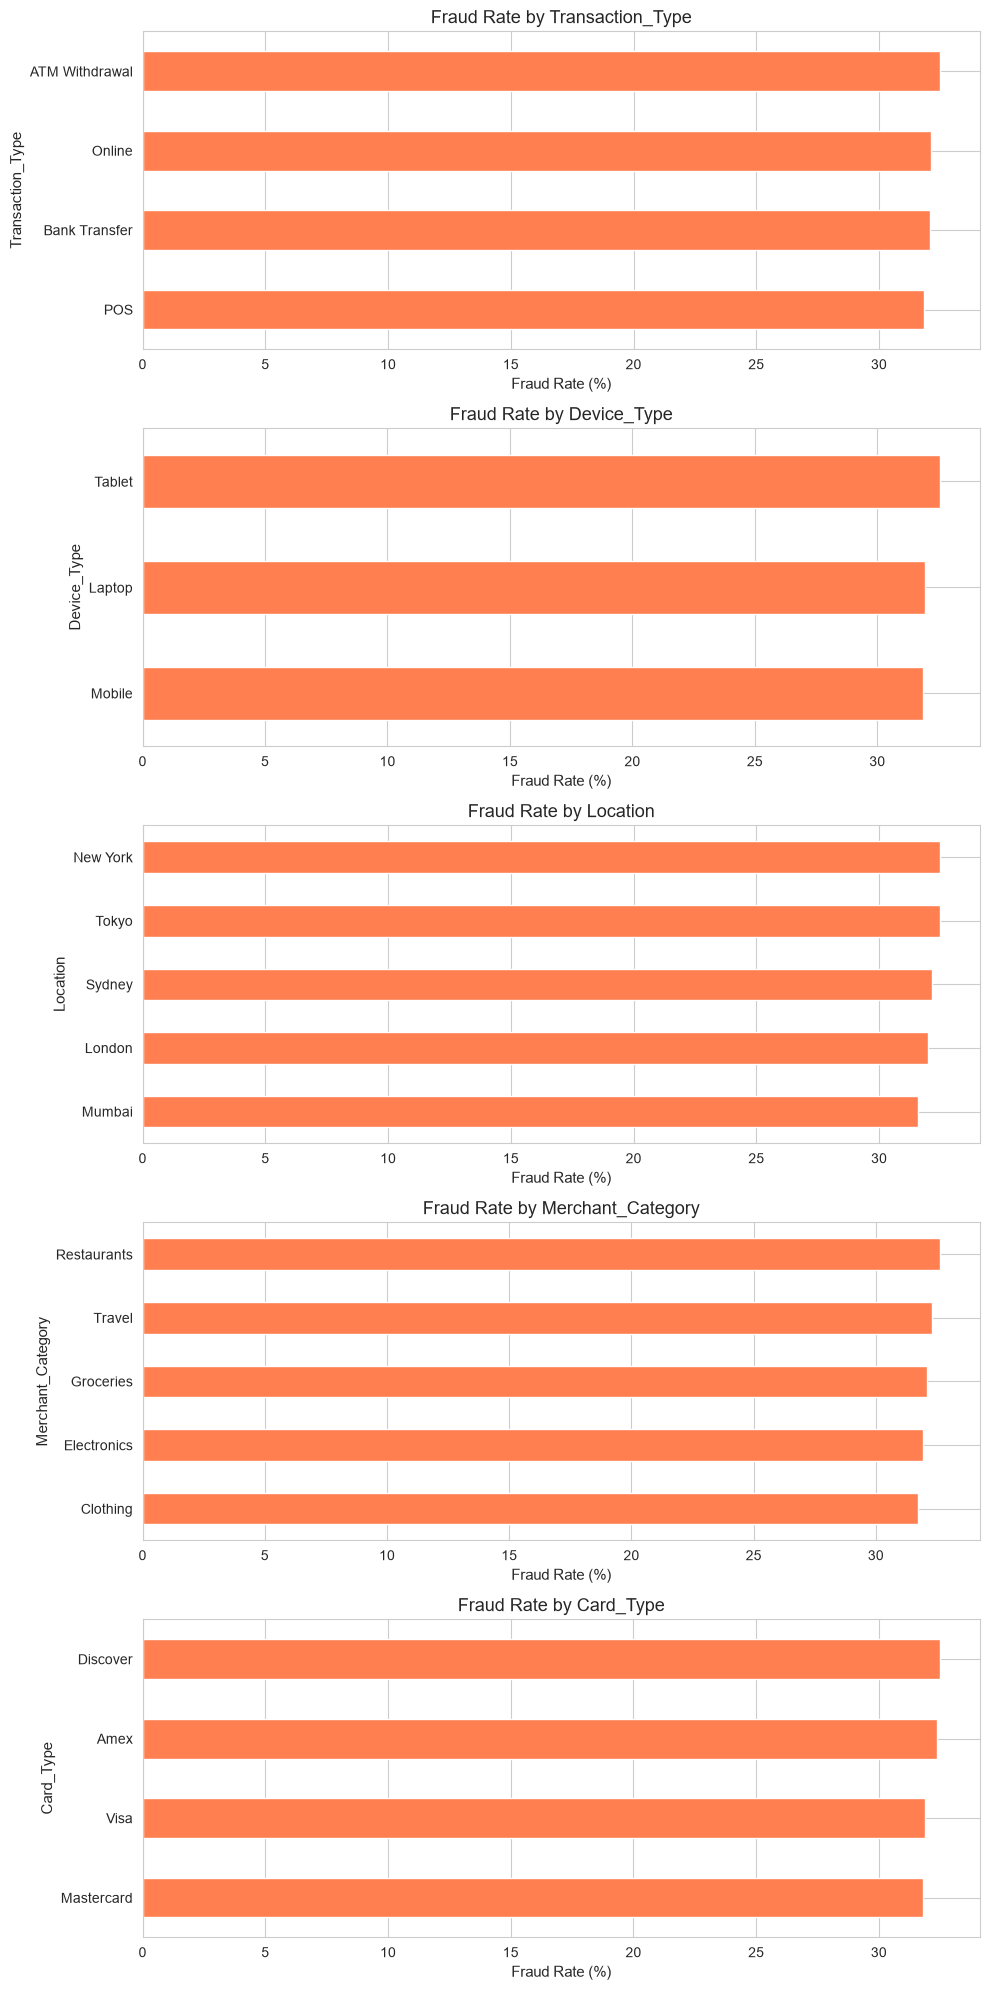

In [29]:
# Fraud rate by categorical features
if available_cat:
    n = len(available_cat)
    fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n))
    if n == 1:
        axes = [axes]

    for i, col in enumerate(available_cat):
        # Limit to top 15 categories if high-cardinality
        top_n = 15 if df[col].nunique() > 15 else None
        fraud_rate_bar(df, col, TARGET_COL, axes[i], top_n=top_n)

    plt.tight_layout()
    plt.show()

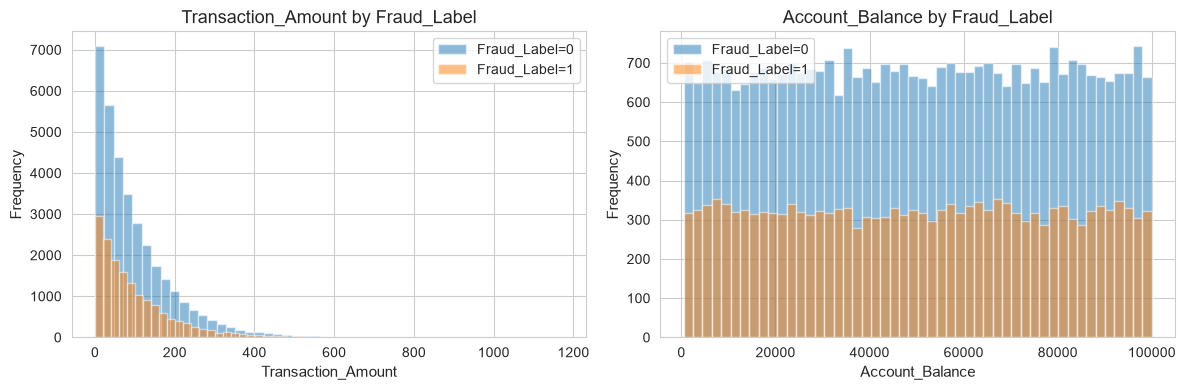

In [30]:
# Numerical feature distributions by fraud label
if available_num:
    n = len(available_num)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]

    for i, col in enumerate(available_num):
        for label in sorted(df[TARGET_COL].unique()):
            subset = df[df[TARGET_COL] == label][col].dropna()
            axes[i].hist(subset, bins=50, alpha=0.5, label=f"{TARGET_COL}={label}")
        axes[i].set_title(f"{col} by {TARGET_COL}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")
        axes[i].legend()

    plt.tight_layout()
    plt.show()

---
## 16. Data Quality Observations

In [31]:
print("=" * 60)
print("DATA QUALITY OBSERVATIONS")
print("=" * 60)

# --- Facts from data ---
print("\n📋 FACTS FROM DATA\n")

# Missing data
total_missing = df.isnull().sum().sum()
if total_missing == 0:
    print("• Missing values  : None detected.")
else:
    cols_missing = df.columns[df.isnull().any()].tolist()
    print(f"• Missing values  : {total_missing:,} total across columns: {cols_missing}")

# Duplicates
print(f"• Duplicate rows  : {num_duplicates:,} ({dup_pct:.2f}%)")

# Class balance
majority_pct = target_pcts.max()
minority_pct = target_pcts.min()
print(f"• Class balance   : Majority class = {majority_pct:.1f}%, Minority class = {minority_pct:.1f}%")
if minority_pct < 10:
    print("  → Highly imbalanced dataset — consider resampling strategies later.")
elif minority_pct < 30:
    print("  → Moderately imbalanced dataset.")
else:
    print("  → Relatively balanced dataset.")

# High-cardinality / IDs
if id_candidates:
    id_names = [c["Column"] for c in id_candidates]
    print(f"• Identifier cols : {id_names}")
else:
    print("• Identifier cols : None detected.")

# Date columns
if potential_date_cols:
    print(f"• Date columns    : {potential_date_cols}")
else:
    print("• Date columns    : None detected.")

# Row / column counts
print(f"• Dataset size    : {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\n" + "-" * 60)
print("\n🔍 ITEMS TO INVESTIGATE IN LATER NOTEBOOKS\n")
print("• Decide how to handle identifier columns (drop or use for grouping).")
if potential_date_cols:
    print("• Extract temporal features from date column(s).")
if total_missing > 0:
    print("• Determine imputation strategy for missing values.")
if num_duplicates > 0:
    print("• Investigate and decide whether to remove duplicate rows.")
if minority_pct < 30:
    print("• Address class imbalance (SMOTE, under-sampling, class weights, etc.).")
print("• Perform full EDA and feature engineering.")
print("• Encode categorical variables for modelling.")
print("• Check for outliers in numerical columns and decide handling strategy.")

DATA QUALITY OBSERVATIONS

📋 FACTS FROM DATA

• Missing values  : None detected.
• Duplicate rows  : 0 (0.00%)
• Class balance   : Majority class = 67.9%, Minority class = 32.1%
  → Relatively balanced dataset.
• Identifier cols : ['Transaction_ID', 'User_ID', 'Account_Balance']
• Date columns    : ['Date']
• Dataset size    : 50,000 rows × 14 columns

------------------------------------------------------------

🔍 ITEMS TO INVESTIGATE IN LATER NOTEBOOKS

• Decide how to handle identifier columns (drop or use for grouping).
• Extract temporal features from date column(s).
• Perform full EDA and feature engineering.
• Encode categorical variables for modelling.
• Check for outliers in numerical columns and decide handling strategy.


---
## 17. Key Findings and Next Steps

### Key Findings

The findings below were generated dynamically from the dataset and should be verified when the notebook is executed.

| Aspect | Observation |
|---|---|
| **Dataset size** | Determined at runtime (see Section 4) |
| **Target variable** | `Fraud_Label` — binary (0/1) |
| **Missing values** | Reported in Section 8 |
| **Duplicates** | Reported in Section 9 |
| **Identifiers** | Reported in Section 12 |
| **Date columns** | Reported in Section 13 |
| **Correlation** | See heatmap in Section 14 |

### Considerations for Next Notebook

- Handle missing values (if any) with an appropriate imputation strategy.
- Decide on duplicate row handling.
- Drop or restructure identifier columns.
- Extract temporal features from date column(s).
- Encode categorical variables.
- Address class imbalance if present.
- Investigate and handle outliers in numerical features.

---

**Next notebook: `02_data_cleaning.ipynb`**